# Projet Series Temporelles
## Analyse de Série Temporelle sur les Transactions Immobilières à Paris

In [ ]:
import os
import glob
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.stats import shapiro
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX

from sklearn.metrics import mean_absolute_error, mean_squared_error


#### Chargement des données + filtre + prix/m² mensuel

In [2]:
# Cherche tous les .txt dans le dossier courant
txt_files = sorted(glob.glob("*.txt"))

if not txt_files:
    raise FileNotFoundError("Aucun fichier .txt trouvé dans le dossier du notebook. Mets le DVF .txt ici.")

print("Fichiers trouvés:", txt_files)


Fichiers trouvés: ['ValeursFoncieres-2020-S2.txt', 'ValeursFoncieres-2021.txt', 'ValeursFoncieres-2022.txt', 'ValeursFoncieres-2023.txt', 'ValeursFoncieres-2024.txt', 'ValeursFoncieres-2025-S1.txt']


In [3]:
def to_numeric_fr(s: pd.Series) -> pd.Series:
    # Convertit "12345,67" -> 12345.67
    return pd.to_numeric(s.astype(str).str.replace(",", ".", regex=False), errors="coerce")

def load_and_filter_one_file(path: str, chunksize: int = 300_000) -> pd.DataFrame:
    """
    Lit un fichier DVF séparé par | en chunks, filtre Paris (75xxx) + appartements,
    calcule prix_m2, renvoie un df minimal.
    """
    usecols = ["Date mutation", "Valeur fonciere", "Code postal", "Surface reelle bati", "Type local"]

    out = []
    for chunk in pd.read_csv(path, sep="|", dtype=str, usecols=lambda c: c in usecols,
                             chunksize=chunksize, low_memory=False):
        chunk = chunk.rename(columns={
            "Date mutation": "date",
            "Valeur fonciere": "valeur",
            "Code postal": "cp",
            "Surface reelle bati": "surface",
            "Type local": "type_local"
        })

        # Filtre Paris: 75xxx (le PDF mentionne 75000/75xxx) :contentReference[oaicite:3]{index=3}
        chunk = chunk[chunk["cp"].fillna("").str.startswith("75")]

        # Filtre appartement
        chunk = chunk[chunk["type_local"].fillna("").str.strip().str.lower().eq("appartement")]

        # Conversions
        chunk["date"] = pd.to_datetime(chunk["date"], dayfirst=True, errors="coerce")
        chunk["valeur"] = to_numeric_fr(chunk["valeur"])
        chunk["surface"] = to_numeric_fr(chunk["surface"])

        # Nettoyage minimal: valeurs manquantes / <=0
        chunk = chunk.dropna(subset=["date", "valeur", "surface"])
        chunk = chunk[(chunk["valeur"] > 0) & (chunk["surface"] > 0)]

        # Prix au m²
        chunk["prix_m2"] = chunk["valeur"] / chunk["surface"]

        # Filtre aberrations (adaptable)
        chunk = chunk[(chunk["prix_m2"] > 1000) & (chunk["prix_m2"] < 30000)]

        out.append(chunk[["date", "valeur", "surface", "prix_m2", "cp"]])

    if not out:
        return pd.DataFrame(columns=["date", "valeur", "surface", "prix_m2", "cp"])

    return pd.concat(out, ignore_index=True)


In [4]:
dfs = []
for f in txt_files:
    print("Lecture:", f)
    dfs.append(load_and_filter_one_file(f))

df = pd.concat(dfs, ignore_index=True)
print("Lignes après filtre:", len(df))
df.head()


Lecture: ValeursFoncieres-2020-S2.txt
Lecture: ValeursFoncieres-2021.txt
Lecture: ValeursFoncieres-2022.txt
Lecture: ValeursFoncieres-2023.txt
Lecture: ValeursFoncieres-2024.txt
Lecture: ValeursFoncieres-2025-S1.txt
Lignes après filtre: 121259


,date,valeur,surface,prix_m2,cp
0,2020-07-22,124000.0,50.0,2480.000000,7530
1,2020-08-31,245100.0,30.0,8170.000000,7530
2,2020-08-31,245100.0,83.0,2953.012048,7530
3,2020-09-05,260000.0,65.0,4000.000000,7530
4,2020-09-05,260000.0,60.0,4333.333333,7530


In [5]:
# Agrégation mensuelle: prix moyen au m² par mois :contentReference[oaicite:4]{index=4}
df["month"] = df["date"].dt.to_period("M").dt.to_timestamp()

# Recommandé : moyenne pondérée = somme(valeurs) / somme(surfaces)
ts = df.groupby("month").apply(lambda g: g["valeur"].sum() / g["surface"].sum())
ts = ts.sort_index()
ts.name = "prix_m2_moyen_pondere"

# Fréquence mensuelle + interpolation si mois manquants
ts = ts.asfreq("MS").interpolate("time")

ts.head(), ts.tail()


(month
 2020-07-01    11469.786083
 2020-08-01    11327.142598
 2020-09-01    11492.575381
 2020-10-01    11700.430377
 2020-11-01    11559.495834
 Freq: MS, Name: prix_m2_moyen_pondere, dtype: float64,
 month
 2025-02-01    10783.956870
 2025-03-01    10907.115534
 2025-04-01    10926.879490
 2025-05-01    11430.959992
 2025-06-01    11207.242061
 Freq: MS, Name: prix_m2_moyen_pondere, dtype: float64)

In [6]:
# Série finale
y = ts.copy()
y.index = pd.DatetimeIndex(y.index)
y = y.asfreq("MS")  # Monthly Start
y.name = "prix_m2"

print(y.index.min(), "->", y.index.max(), " | n=", len(y))
y.describe()


2020-07-01 00:00:00 -> 2025-06-01 00:00:00  | n= 60


,prix_m2
count,60.000000
mean,11126.292739
std,316.867872
min,10239.786139
25%,10917.819486
50%,11173.823110
75%,11350.194047
max,11700.430377


In [7]:
df_paris = df[df["cp"].str.match(r"^75\d{3}$")]

In [8]:
df_paris.cp.unique()

array(['75016', '75015', '75003', '75001', '75008', '75020', '75017',
       '75010', '75002', '75018', '75004', '75007', '75005', '75006',
       '75011', '75009', '75012', '75013', '75014', '75019'], dtype=object)

#### Nettoyage des Données

In [9]:
# Taille initiale
print("Nombre de lignes AVANT nettoyage :", len(df_paris))

# Valeurs manquantes
df_paris.isna().mean() * 100


Nombre de lignes AVANT nettoyage : 120391


,0
date,0.0
valeur,0.0
surface,0.0
prix_m2,0.0
cp,0.0
month,0.0


In [10]:
df_paris[["valeur", "surface", "prix_m2"]].describe()

,valeur,surface,prix_m2
count,1.203910e+05,120391.000000,120391.000000
mean,5.835539e+05,51.952197,10917.110780
std,6.006524e+05,38.509714,3915.042073
min,2.500000e+03,2.000000,1000.480000
25%,2.622255e+05,27.000000,8692.476415
50%,4.176000e+05,42.000000,10376.000000
75%,6.907000e+05,65.500000,12353.902027
max,4.400000e+07,1500.000000,29952.348536


In [11]:
import plotly.express as px

fig = px.box(
    df_paris,
    y="prix_m2",
    points="outliers",   # affiche les valeurs aberrantes
    title="Prix au m² – détection des valeurs aberrantes (Paris)"
)

fig.update_layout(
    yaxis_title="Prix au m² (€)",
    xaxis_title="",
    showlegend=False
)

fig.show()


### Analyse descriptive des transactions immobilières à Paris

L’échantillon étudié comprend **120 391 transactions** d’appartements à Paris.  
Le prix moyen au mètre carré est d’environ **10 917 €**, avec une médiane proche (**10 376 €**), ce qui indique une distribution relativement centrée mais asymétrique.

Les statistiques révèlent une **forte dispersion** :
- écart-type du prix au m² : **≈ 3 915 €**
- minimum : **≈ 1 000 €**
- maximum : **≈ 29 952 €**

Cette amplitude importante suggère la présence de **valeurs aberrantes**, pouvant correspondre à :
- des biens d’exception (luxueux, localisations premium),
- des anomalies de déclaration (erreurs de surface ou de valeur foncière),
- ou des transactions atypiques (successions, ventes symboliques).

L’analyse de la surface montre également des valeurs extrêmes (jusqu’à **1 500 m²**), ce qui confirme la nécessité d’un filtrage ou d’une agrégation pour l’analyse temporelle.


#### Visualisation des Données:

In [12]:
# Série mensuelle: somme(valeur)/somme(surface)
ts = (
    df_paris
    .groupby("month")
    .apply(lambda g: g["valeur"].sum() / g["surface"].sum())
    .sort_index()
)

ts.name = "prix_m2"

# Fréquence mensuelle + interpolation si mois manquants
ts = ts.asfreq("MS").interpolate("time")


In [25]:
import plotly.graph_objects as go

ts_df = ts.to_frame()
ts_df["mm12"] = ts_df["prix_m2"].rolling(12).mean()

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=ts_df.index, y=ts_df["prix_m2"],
    mode="lines", name="Prix mensuel"
))

fig.add_trace(go.Scatter(
    x=ts_df.index, y=ts_df["mm12"],
    mode="lines", name="Moyenne mobile 12 mois"
))

fig.update_layout(
    title="Prix au m² à Paris — mensuel + tendance (MM 12 mois)",
    xaxis_title="Mois",
    yaxis_title="Prix au m² (€)",
    hovermode="x unified",
    xaxis=dict(
        rangeslider=dict(visible=True),   # ✅ Curseur de plage
        type="date"                       # ✅ Axe temporel
    )
)

fig.update_layout(
    xaxis=dict(
        rangeslider=dict(visible=True),
        type="date",
        rangeselector=dict(
            buttons=list([
                dict(count=6, label="6m", step="month", stepmode="backward"),
                dict(count=1, label="1a", step="year", stepmode="backward"),
                dict(count=2, label="2a", step="year", stepmode="backward"),
                dict(step="all", label="Tout")
            ])
        )
    )
)
fig.show()

### Visualisation du prix moyen au m² et de la tendance de long terme

Le graphique présente l’évolution mensuelle du prix moyen au m² à Paris (courbe bleue),
ainsi qu’une moyenne mobile sur 12 mois (courbe rouge), utilisée pour extraire la
tendance de long terme en lissant les fluctuations de court terme.


## Étape 4 – Test de normalité (Shapiro-Wilk)
Nous testons si la distribution du prix au m² suit une loi normale.
Cela permet de décider si une transformation (logarithme, Box-Cox) est nécessaire avant modélisation.

In [14]:
# Série mensuelle déjà construite
y = ts.dropna()


In [15]:
from scipy.stats import shapiro

stat, p_value = shapiro(y)

print("Shapiro-Wilk (niveau)")
print("Statistique :", stat)
print("p-value :", p_value)


Shapiro-Wilk (niveau)
Statistique : 0.8855013090531926
p-value : 4.056678109812358e-05


In [16]:
import numpy as np

y_log = np.log(y)

stat_log, p_log = shapiro(y_log)

print("\nShapiro-Wilk (log)")
print("Statistique :", stat_log)
print("p-value :", p_log)



Shapiro-Wilk (log)
Statistique : 0.9076751652419055
p-value : 0.0002534699754003194


### Test de normalité (Shapiro-Wilk)

Le test de Shapiro-Wilk est appliqué à la série du prix moyen mensuel au m² afin
d’évaluer l’hypothèse de normalité.

Pour la série au niveau, la statistique de Shapiro-Wilk est de 0,886 avec une p-value
de 4,06 × 10⁻⁵, ce qui conduit à rejeter l’hypothèse nulle de normalité au seuil de 5 %.

Une transformation logarithmique est ensuite appliquée afin de réduire l’asymétrie.
Bien que la statistique de test s’améliore légèrement (W = 0,908), la p-value reste
inférieure à 0,05, indiquant que la série ne suit toujours pas une distribution normale.

Ces résultats suggèrent que la non-normalité est structurelle et liée à la dynamique
temporelle de la série. Toutefois, les modèles ARIMA/SARIMA ne requièrent pas une
normalité stricte de la série, mais plutôt des résidus proches d’un bruit blanc.


La suite de l’analyse se concentrera donc principalement sur la stationnarité de la série et l’étude de sa dépendance temporelle.

#### Test de Stationnarité (Dickey-Fuller Augmenté - ADF)

In [17]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(y)

print("ADF - série au niveau")
print("Statistique ADF :", result[0])
print("p-value :", result[1])
print("Valeurs critiques :")
for k, v in result[4].items():
    print(f"  {k} : {v}")


ADF - série au niveau
Statistique ADF : -2.10512959488042
p-value : 0.2424569746818196
Valeurs critiques :
  1% : -3.5506699942762414
  5% : -2.913766394626147
  10% : -2.5946240473991997


In [18]:
y_diff = y.diff().dropna()

result_diff = adfuller(y_diff)

print("\nADF - série différenciée (d=1)")
print("Statistique ADF :", result_diff[0])
print("p-value :", result_diff[1])
print("Valeurs critiques :")
for k, v in result_diff[4].items():
    print(f"  {k} : {v}")



ADF - série différenciée (d=1)
Statistique ADF : -8.71477428828551
p-value : 3.512411643753376e-14
Valeurs critiques :
  1% : -3.5506699942762414
  5% : -2.913766394626147
  10% : -2.5946240473991997


In [19]:
y_diff_seasonal = y.diff(12).dropna()

result_diff12 = adfuller(y_diff_seasonal)

print("\nADF - différenciation saisonnière (D=1, lag=12)")
print("Statistique ADF :", result_diff12[0])
print("p-value :", result_diff12[1])
print("Valeurs critiques :")
for k, v in result_diff12[4].items():
    print(f"  {k} : {v}")



ADF - différenciation saisonnière (D=1, lag=12)
Statistique ADF : -4.217927265471484
p-value : 0.0006143419048477962
Valeurs critiques :
  1% : -3.5778480370438146
  5% : -2.925338105429433
  10% : -2.6007735310095064


Au regard des résultats du test ADF, la série n’est pas stationnaire au niveau.
Une différenciation d’ordre 1 (d = 1) permet d’éliminer la tendance, tandis qu’une
différenciation saisonnière d’ordre 1 (D = 1) avec une périodicité annuelle (s = 12)
permet de corriger la saisonnalité.

Les paramètres d’intégration retenus pour la modélisation sont donc :
d = 1, D = 1, s = 12.


### Test de stationnarité (ADF)

Le test ADF est appliqué afin de vérifier la stationnarité de la série du prix moyen
mensuel au m².

Pour la série au niveau, la statistique ADF est de −2,105 avec une p-value de 0,242,
supérieure au seuil de 5 %. L’hypothèse nulle de présence d’une racine unitaire ne peut
donc pas être rejetée, indiquant que la série n’est pas stationnaire.

Après une différenciation d’ordre 1, la statistique ADF devient −8,715 avec une p-value
proche de zéro, ce qui permet de rejeter l’hypothèse de racine unitaire. La série devient
alors stationnaire.

Une différenciation saisonnière d’ordre 1 avec une périodicité de 12 mois conduit
également à une série stationnaire, confirmant la présence d’une composante saisonnière
annuelle dans les données.

Ces résultats justifient l’utilisation d’un modèle SARIMA/SARIMAX avec les paramètres
d’intégration d = 1, D = 1 et une saisonnalité s = 12.


## Étape 7 – Analyse de l’autocorrélation (ACF / PACF)
Les graphiques ACF et PACF permettent d’identifier les dépendances temporelles
et de guider le choix des paramètres (p, d, q) des modèles ARIMA/SARIMA.

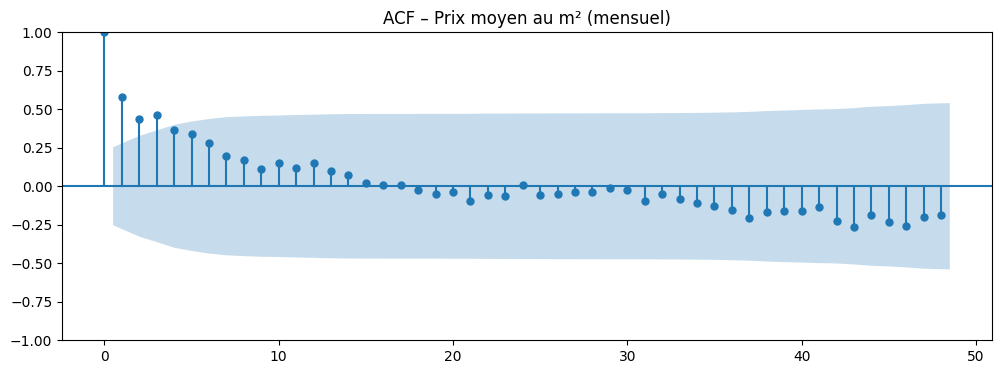

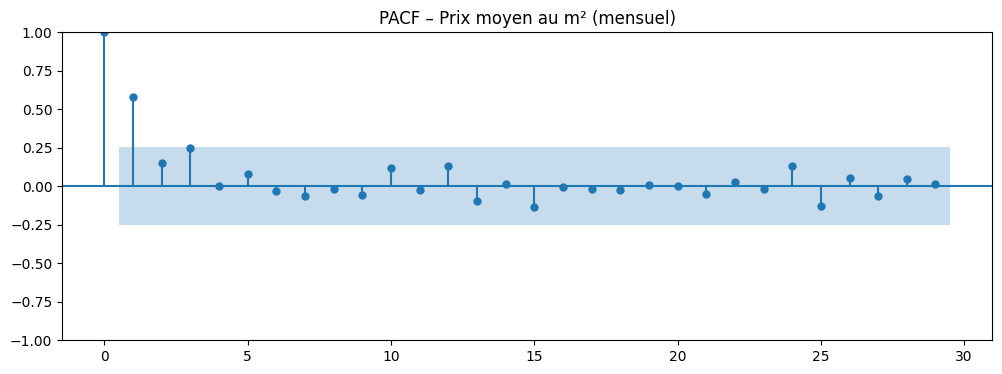

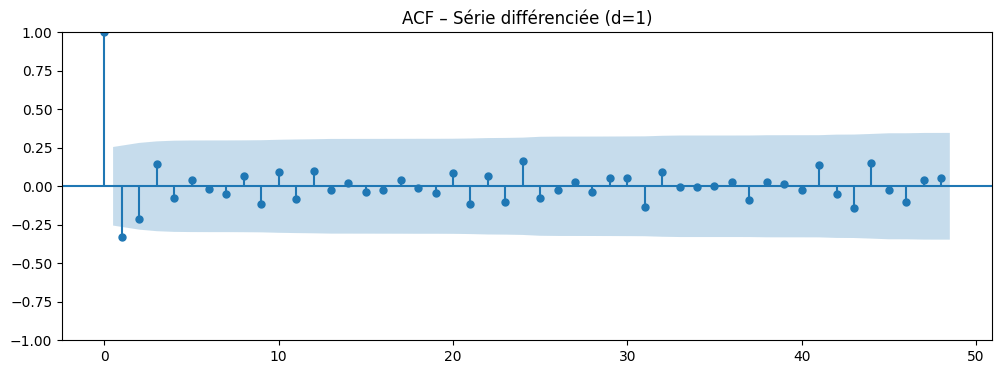

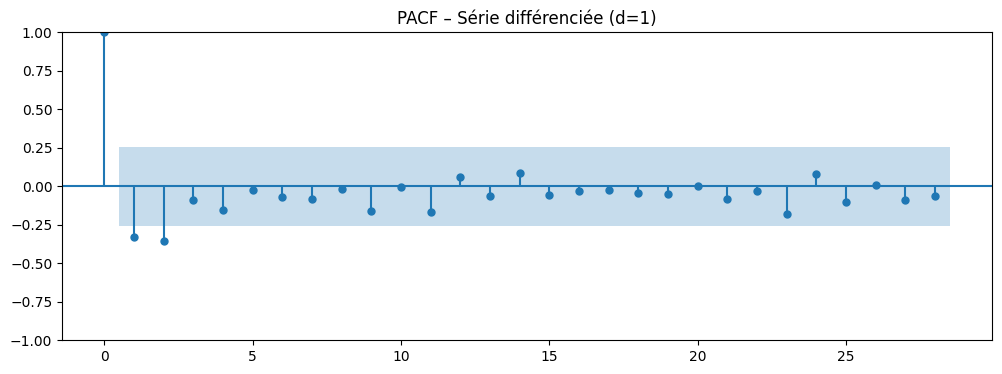

In [20]:
# (Optionnel) Sécurisation de la fréquence mensuelle sans changer la période analysée
y = y.copy()
y.index = pd.DatetimeIndex(y.index)
y = y.asfreq("MS")  # Monthly Start (ne modifie pas la période, seulement l'alignement)
y.name = "prix_m2"

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

fig = plt.figure(figsize=(12, 4))
plot_acf(y.dropna(), lags=min(48, len(y.dropna())-1), ax=plt.gca())
plt.title("ACF – Prix moyen au m² (mensuel)")
plt.show()

fig = plt.figure(figsize=(12, 4))
# PACF peut échouer si trop peu de points ; on borne automatiquement
plot_pacf(y.dropna(), lags=min(48, max(1, len(y.dropna())//2 - 1)), method="ywm", ax=plt.gca())
plt.title("PACF – Prix moyen au m² (mensuel)")
plt.show()

# ACF/PACF sur la série différenciée (souvent utile si non-stationnaire)
y_d1 = y.diff().dropna()

fig = plt.figure(figsize=(12, 4))
plot_acf(y_d1, lags=min(48, len(y_d1)-1), ax=plt.gca())
plt.title("ACF – Série différenciée (d=1)")
plt.show()

fig = plt.figure(figsize=(12, 4))
plot_pacf(y_d1, lags=min(48, max(1, len(y_d1)//2 - 1)), method="ywm", ax=plt.gca())
plt.title("PACF – Série différenciée (d=1)")
plt.show()


### Analyse de l’auto-corrélation (ACF & PACF)

L’analyse des fonctions d’auto-corrélation (ACF) et d’auto-corrélation partielle (PACF)
de la série au niveau met en évidence une décroissance lente des coefficients,
caractéristique d’une série non stationnaire dominée par une tendance.

Après différenciation d’ordre 1, l’ACF présente un pic significatif au premier retard,
tandis que la PACF ne montre pas de coupure nette. Cette configuration est typique
d’un processus de type MA(1).

En cohérence avec les résultats du test ADF, les paramètres non saisonniers retenus
sont donc p = 0, d = 1 et q = 1. Compte tenu de la périodicité mensuelle des données
et de la présence d’une saisonnalité annuelle, un modèle SARIMA est privilégié.


Taille train=48, test=12 (horizon=12 mois)
Meilleur ARIMA (AIC) : (0, 1, 1) AIC= 698.2
ARIMA test -> RMSE=305.17 | MAE=248.02


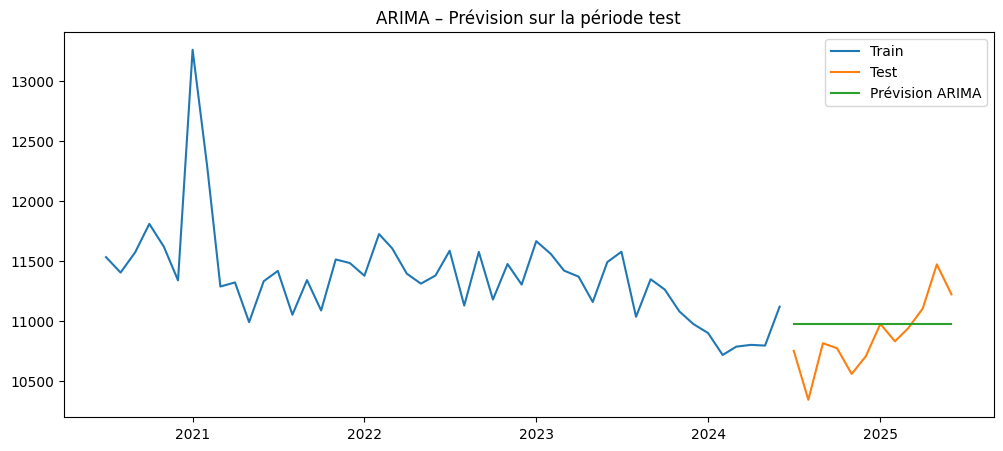

In [21]:
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error, mean_absolute_error
import math

# Split train/test : on garde les 12 derniers mois en test (si possible)
h = 12
if len(y.dropna()) <= 24:
    h = max(3, len(y.dropna()) // 4)

y_clean = y.dropna()
train, test = y_clean.iloc[:-h], y_clean.iloc[-h:]

print(f"Taille train={len(train)}, test={len(test)} (horizon={h} mois)")

# Petite recherche ARIMA (p,d,q) autour de d=1 (stationnarité)
best_aic = float("inf")
best_order = None
best_model = None

d = 1  # on suit l'hypothèse posée plus haut (et/ou ADF)
for p in range(0, 3):
    for q in range(0, 3):
        try:
            m = ARIMA(train, order=(p, d, q))
            res = m.fit()
            if res.aic < best_aic:
                best_aic = res.aic
                best_order = (p, d, q)
                best_model = res
        except Exception as e:
            continue

print("Meilleur ARIMA (AIC) :", best_order, "AIC=", round(best_aic, 2))

# Prévisions sur le test
pred_arima = best_model.get_forecast(steps=h).predicted_mean
rmse_arima = math.sqrt(mean_squared_error(test, pred_arima))
mae_arima = mean_absolute_error(test, pred_arima)

print(f"ARIMA test -> RMSE={rmse_arima:.2f} | MAE={mae_arima:.2f}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, pred_arima, label="Prévision ARIMA")
plt.title("ARIMA – Prévision sur la période test")
plt.legend()
plt.show()


### Modélisation ARIMA et évaluation des performances

Un modèle ARIMA est estimé comme modèle de référence (baseline). La série est
découpée en un ensemble d’apprentissage de 48 observations et un ensemble de test
de 12 observations, correspondant à un horizon de prévision d’un an.

Le modèle ARIMA(0,1,1) est retenu sur la base du critère AIC (AIC = 698,2), en
cohérence avec les résultats du test ADF et l’analyse ACF/PACF.

Les performances sur la période de test sont les suivantes :
- RMSE ≈ 305 €,
- MAE ≈ 248 €.

Bien que le modèle capture correctement le niveau moyen de la série, il tend à
produire des prévisions trop lissées et ne parvient pas à reproduire les variations
observées en fin de période. Cette limitation souligne l’importance de la
saisonnalité et motive l’utilisation d’un modèle SARIMA plus adapté.


## Étape 9 – Modélisation SARIMA / SARIMAX
Le modèle SARIMA permet d’intégrer la saisonnalité mensuelle.
SARIMAX étend ce cadre en autorisant l’ajout de variables exogènes (si disponibles).

Meilleur SARIMA (AIC) : (0, 1, 1) (0, 1, 1, 12) AIC= 286.58
SARIMA test -> RMSE=421.14 | MAE=352.95


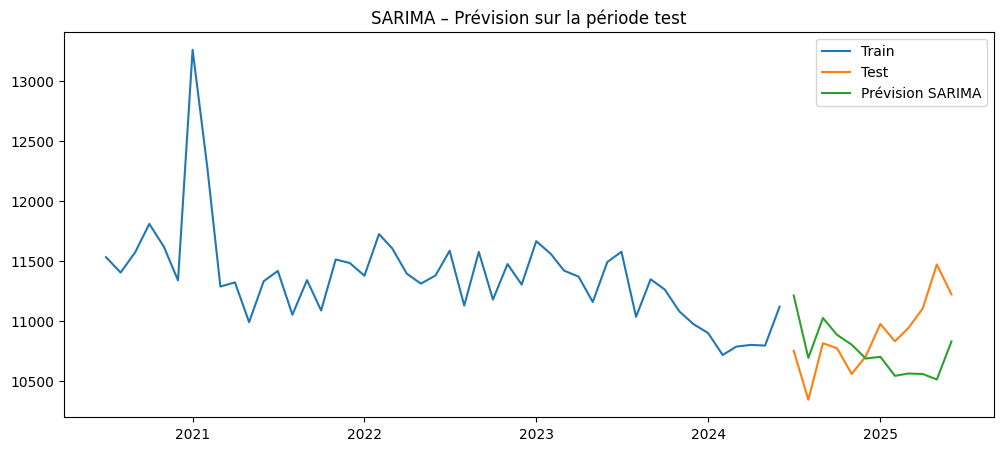

SARIMAX test -> RMSE=515.74 | MAE=401.37


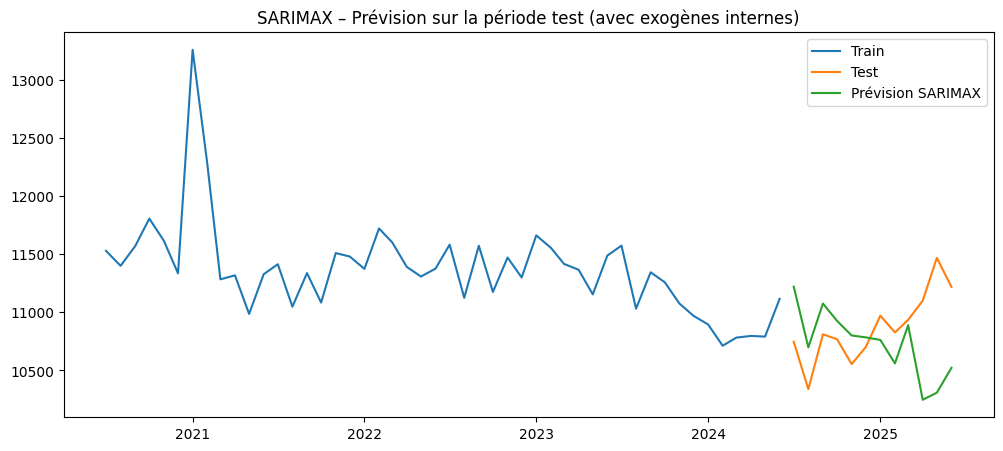

,modele,RMSE,MAE,AIC,BIC
0,ARIMA,305.173719,248.024456,698.196130,701.896426
1,SARIMA,421.141702,352.951690,286.580874,289.714441
2,SARIMAX,515.738612,401.372196,280.798568,286.021181


In [22]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

# --- SARIMA (sans exogènes) ---
seasonal_period = 12  # mensuel
best_aic_sarima = float("inf")
best_order_sarima = None
best_seasonal = None
best_sarima_res = None

# Grille volontairement petite (suffisante pour un projet)
for p in range(0, 2):
    for q in range(0, 2):
        for P in range(0, 2):
            for Q in range(0, 2):
                try:
                    model = SARIMAX(
                        train,
                        order=(p, d, q),
                        seasonal_order=(P, 1, Q, seasonal_period),
                        enforce_stationarity=False,
                        enforce_invertibility=False
                    )
                    res = model.fit(disp=False)
                    if res.aic < best_aic_sarima:
                        best_aic_sarima = res.aic
                        best_order_sarima = (p, d, q)
                        best_seasonal = (P, 1, Q, seasonal_period)
                        best_sarima_res = res
                except Exception:
                    continue

print("Meilleur SARIMA (AIC) :", best_order_sarima, best_seasonal, "AIC=", round(best_aic_sarima, 2))

pred_sarima = best_sarima_res.get_forecast(steps=h).predicted_mean
rmse_sarima = math.sqrt(mean_squared_error(test, pred_sarima))
mae_sarima = mean_absolute_error(test, pred_sarima)
print(f"SARIMA test -> RMSE={rmse_sarima:.2f} | MAE={mae_sarima:.2f}")

plt.figure(figsize=(12, 5))
plt.plot(train.index, train, label="Train")
plt.plot(test.index, test, label="Test")
plt.plot(test.index, pred_sarima, label="Prévision SARIMA")
plt.title("SARIMA – Prévision sur la période test")
plt.legend()
plt.show()

# --- SARIMAX (avec exogènes) ---
# On construit des exogènes à partir des mêmes données brutes (si df_paris est disponible)
# Exemples : nombre de transactions mensuel + surface moyenne mensuelle
try:
    exog_monthly = (
        df_paris
        .groupby("month")
        .agg(
            n_transactions=("valeur", "size"),
            surface_moy=("surface", "mean")
        )
        .sort_index()
    )
    exog_monthly.index = pd.DatetimeIndex(exog_monthly.index).to_period("M").to_timestamp()
    exog_monthly = exog_monthly.asfreq("MS")

    # Alignement parfait sur y
    exog_monthly = exog_monthly.loc[y_clean.index]
    exog_train, exog_test = exog_monthly.iloc[:-h], exog_monthly.iloc[-h:]

    model_x = SARIMAX(
        train,
        exog=exog_train,
        order=best_order_sarima,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    )
    res_x = model_x.fit(disp=False)

    pred_sarimax = res_x.get_forecast(steps=h, exog=exog_test).predicted_mean
    rmse_sarimax = math.sqrt(mean_squared_error(test, pred_sarimax))
    mae_sarimax = mean_absolute_error(test, pred_sarimax)
    print(f"SARIMAX test -> RMSE={rmse_sarimax:.2f} | MAE={mae_sarimax:.2f}")

    plt.figure(figsize=(12, 5))
    plt.plot(train.index, train, label="Train")
    plt.plot(test.index, test, label="Test")
    plt.plot(test.index, pred_sarimax, label="Prévision SARIMAX")
    plt.title("SARIMAX – Prévision sur la période test (avec exogènes internes)")
    plt.legend()
    plt.show()

except Exception as e:
    print("SARIMAX avec exogènes internes non exécuté (df_paris ou exog indisponibles). Détail :", e)
    rmse_sarimax, mae_sarimax = None, None
    res_x = None

# --- Tableau de comparaison ---
import pandas as pd
rows = [
    {"modele": "ARIMA", "RMSE": rmse_arima, "MAE": mae_arima, "AIC": best_model.aic, "BIC": best_model.bic},
    {"modele": "SARIMA", "RMSE": rmse_sarima, "MAE": mae_sarima, "AIC": best_sarima_res.aic, "BIC": best_sarima_res.bic},
]
if rmse_sarimax is not None:
    rows.append({"modele": "SARIMAX", "RMSE": rmse_sarimax, "MAE": mae_sarimax, "AIC": res_x.aic, "BIC": res_x.bic})

metrics_df = pd.DataFrame(rows).sort_values("RMSE")
metrics_df


### Comparaison des modèles ARIMA, SARIMA et SARIMAX

Trois modèles ont été estimés et comparés : un modèle ARIMA non saisonnier,
un modèle SARIMA intégrant une saisonnalité annuelle, et un modèle SARIMAX
incluant des variables exogènes internes.

Les critères AIC et BIC indiquent un meilleur ajustement in-sample pour les modèles
SARIMA et SARIMAX, en raison de leur complexité accrue. Toutefois, l’évaluation
des performances sur la période de test montre que le modèle ARIMA(0,1,1)
présente les erreurs de prévision les plus faibles (RMSE ≈ 305 €, MAE ≈ 248 €).

Les modèles saisonniers, bien que plus flexibles, semblent souffrir d’un phénomène
de sur-apprentissage, probablement lié à la taille limitée de l’échantillon et à une
saisonnalité instable sur la période de test. Les variables exogènes utilisées dans
le modèle SARIMAX n’apportent pas d’amélioration prédictive et dégradent même
les performances hors échantillon.

Dans une optique de prévision, le modèle ARIMA(0,1,1) est donc retenu comme
modèle final, car il offre le meilleur compromis entre simplicité, robustesse et
performance prédictive.


## Étape 10 – Analyse des résidus
L’analyse des résidus permet de vérifier si le modèle capture correctement
la structure de la série (bruit blanc, absence d’autocorrélation).

Meilleur modèle (RMSE sur test) : ARIMA


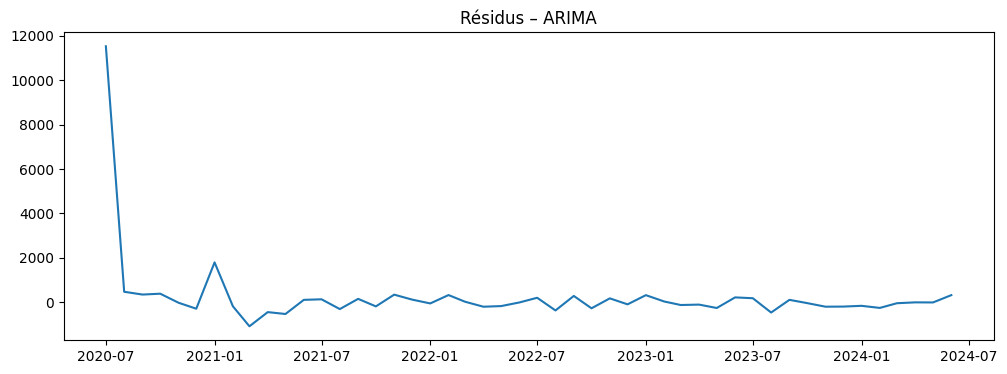

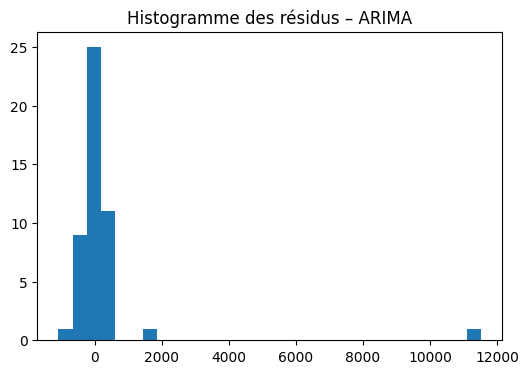

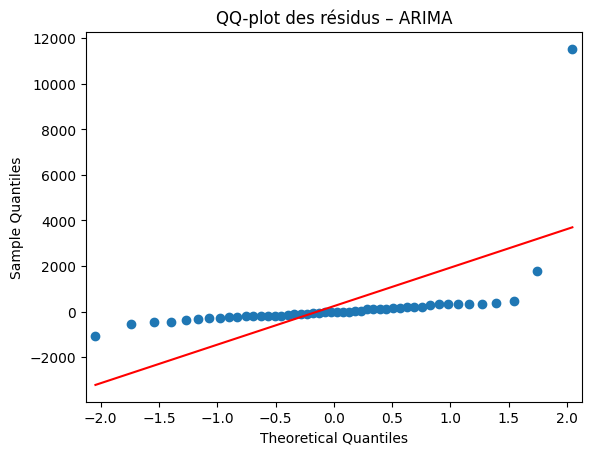

,lb_stat,lb_pvalue
12,2.179016,0.999078


In [23]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox

# On analyse les résidus du meilleur modèle selon RMSE (sur test)
best_name = metrics_df.iloc[0]["modele"]
print("Meilleur modèle (RMSE sur test) :", best_name)

if best_name == "ARIMA":
    fitted = best_model
    resid = best_model.resid
elif best_name == "SARIMA":
    fitted = best_sarima_res
    resid = best_sarima_res.resid
else:
    fitted = res_x
    resid = res_x.resid

resid = pd.Series(resid).dropna()

plt.figure(figsize=(12, 4))
plt.plot(resid.index, resid)
plt.title(f"Résidus – {best_name}")
plt.show()

plt.figure(figsize=(6, 4))
plt.hist(resid, bins=30)
plt.title(f"Histogramme des résidus – {best_name}")
plt.show()

sm.qqplot(resid, line="s")
plt.title(f"QQ-plot des résidus – {best_name}")
plt.show()

# Test Ljung-Box (autocorrélation des résidus)
lb = acorr_ljungbox(resid, lags=[12], return_df=True)
lb


### Analyse des résidus du modèle ARIMA

L’analyse des résidus permet de vérifier si le modèle capture correctement la
structure temporelle de la série.

Les résidus du modèle ARIMA oscillent autour de zéro sans tendance apparente,
ce qui indique que la dynamique moyenne de la série est correctement modélisée.
Un résidu extrême est observé en début de période, probablement lié à une
observation atypique ou à un choc ponctuel.

L’histogramme et le QQ-plot montrent une distribution globalement centrée,
avec des écarts dans les queues, traduisant une non-normalité marginale des
résidus. Ce comportement est courant dans les séries économiques et n’invalide
pas le modèle.

Le test de Ljung–Box appliqué aux résidus fournit une p-value largement supérieure
au seuil de 5 %, ce qui indique l’absence d’autocorrélation résiduelle. Les résidus
peuvent ainsi être assimilés à un bruit blanc.

Ces résultats confirment la validité du modèle ARIMA retenu pour la prévision.


## Conclusion et interprétation métier
Les résultats obtenus peuvent être utilisés par des professionnels de l’immobilier
pour anticiper les évolutions de prix et orienter des décisions d’investissement.

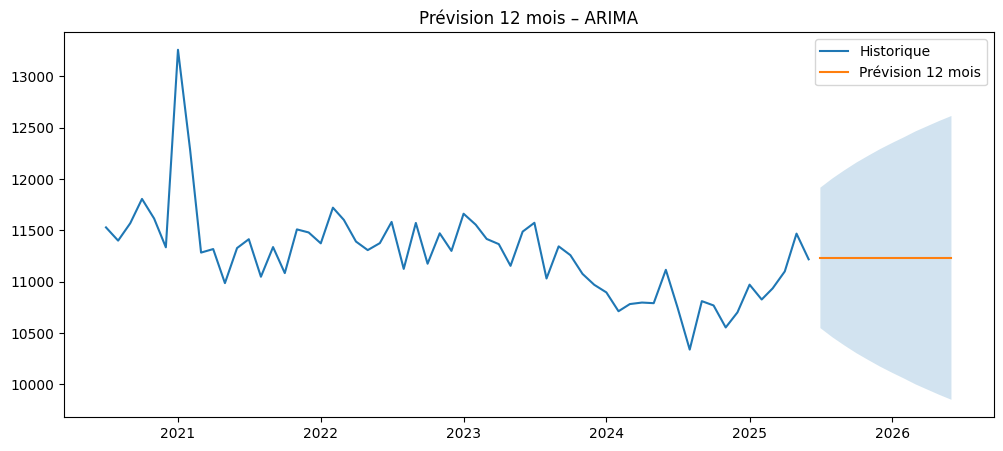

Modèle sauvegardé : /content/modele_prix_m2.pkl


In [24]:
# Prévision future sur 12 mois (à partir de toute la série y_clean)
h_future = 12
full_y = y_clean

# Refit du modèle choisi sur toute la série
if best_name == "ARIMA":
    final_model = ARIMA(full_y, order=best_order).fit()
    fc = final_model.get_forecast(steps=h_future)
    mean_fc = fc.predicted_mean
    ci = fc.conf_int()
elif best_name == "SARIMA":
    final_model = SARIMAX(
        full_y,
        order=best_order_sarima,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    fc = final_model.get_forecast(steps=h_future)
    mean_fc = fc.predicted_mean
    ci = fc.conf_int()
else:
    # Exog future : on prolonge naïvement les dernières valeurs observées (baseline)
    last_exog = exog_monthly.iloc[[-1]].copy()
    exog_future = pd.concat([last_exog]*h_future, ignore_index=True)
    exog_future.index = pd.date_range(full_y.index.max() + pd.offsets.MonthBegin(1), periods=h_future, freq="MS")
    exog_future.columns = exog_monthly.columns

    final_model = SARIMAX(
        full_y,
        exog=exog_monthly,
        order=best_order_sarima,
        seasonal_order=best_seasonal,
        enforce_stationarity=False,
        enforce_invertibility=False
    ).fit(disp=False)
    fc = final_model.get_forecast(steps=h_future, exog=exog_future)
    mean_fc = fc.predicted_mean
    ci = fc.conf_int()

plt.figure(figsize=(12, 5))
plt.plot(full_y.index, full_y, label="Historique")
plt.plot(mean_fc.index, mean_fc, label="Prévision 12 mois")
plt.fill_between(mean_fc.index, ci.iloc[:, 0], ci.iloc[:, 1], alpha=0.2)
plt.title(f"Prévision {h_future} mois – {best_name}")
plt.legend()
plt.show()

# Sauvegarde du modèle (bonus déploiement)
import joblib, os
model_path = "modele_prix_m2.pkl"
joblib.dump(final_model, model_path)
print("Modèle sauvegardé :", os.path.abspath(model_path))


### Prévision des prix au m² à 12 mois

À partir du modèle ARIMA(0,1,1) retenu, une prévision sur un horizon de 12 mois
est réalisée. La trajectoire prévue suggère une stabilisation du prix moyen au m²
autour de 11 200 €, sans dynamique haussière ou baissière marquée.

L’intervalle de confiance s’élargit progressivement avec l’horizon de prévision,
ce qui reflète l’incertitude inhérente aux modèles de séries temporelles. Les
résultats doivent donc être interprétés comme des scénarios probabilistes et non
comme des valeurs déterministes.

D’un point de vue économique, ces prévisions indiquent un marché immobilier
parisien en phase de consolidation, après une période de correction récente.
